In [2]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
import sys

sys.path.append('/Users/hedge/PyCharmProjects/dev')

from boats.lib.common import *
from boats.lib.boat import Boat



In [3]:
boatname = 'Petsamo'

sails = ['Nr.1', 'Nr.2', 'Nr.3', 'Stormjib', 'Mainsail', 'Genaker', 'Mizzen', 'Mizzen staysail']
points_of_sail={
    'close haul': list(range(0,37)),
    'close reach': list(range(36,73)),
    'beam': list(range(72,109)),
    'broad reach': list(range(108,145)),
    'run': list(range(144,181))
}
yesmark = 'x'
nomark = '-'

In [4]:
boat=Boat(boatname)

In [5]:
df = boat.nav.log.df

In [6]:
df.tail()

,tws,spd,twd,twa,awa,heel,lat,lon,sails,hdg
2025-01-04 15:32:51.913475990,23.2,5.6,296,54,45,30,-33.82692,-45.43593,"[Mizzen, Nr.2]",242.0
2025-01-04 16:08:20.360716105,22.9,5.6,293,51,42,29,-33.85012,-45.48291,"[Mizzen, Nr.2]",242.0
2025-01-04 17:18:05.321851969,20.2,4.0,278,37,31,23,-33.89882,-45.58265,"[Mizzen, Nr.2]",242.0
2025-01-04 17:55:15.007054090,18.4,5.4,266,57,44,29,-33.95033,-45.61775,"[Mainsail, Mizzen, Nr.2]",209.0
2025-01-04 18:12:12.349169970,17.7,4.8,259,51,43,27,-33.97263,-45.63047,"[Mainsail, Mizzen, Nr.2]",209.0


In [7]:
boat.nav.log.last_record_timestamp

'04-Jan 18:12'

In [8]:

#df.dropna(inplace=True)
df['heel']=df['heel'].apply(lambda x: int(abs(x)))
df['twd']=df['twd'].apply(lambda x: round(x,0))
df['twa']=df['twa'].apply(lambda x: abs(x))
df=df[df['spd']!=0]
df.head()

,tws,spd,twd,twa,awa,heel,lat,lon,sails,hdg
2024-10-08 00:11:39.603251934,15.7,4.4,71,54,43,27,44.44315,-60.33986,"[Mainsail, Mizzen, Nr.3]",NaN
2024-10-08 00:12:08.685408115,15.7,4.4,71,54,43,27,44.44315,-60.33986,"[Mainsail, Mizzen, Nr.3]",NaN
2024-10-08 00:12:43.100683928,15.7,4.4,71,54,43,27,44.44315,-60.33986,"[Mainsail, Mizzen, Nr.3]",NaN
2024-10-08 00:17:00.234331846,15.7,4.4,71,54,43,27,44.44315,-60.33986,"[Mainsail, Mizzen, Nr.3]",NaN
2024-10-08 00:18:40.694143057,15.7,4.4,71,54,43,27,44.44315,-60.33986,"[Mainsail, Mizzen, Nr.3]",NaN


In [9]:
len(df)

1571

In [10]:
df.index[-1].strftime('%d-%b-%y %H:%M')

'04-Jan-25 18:12'

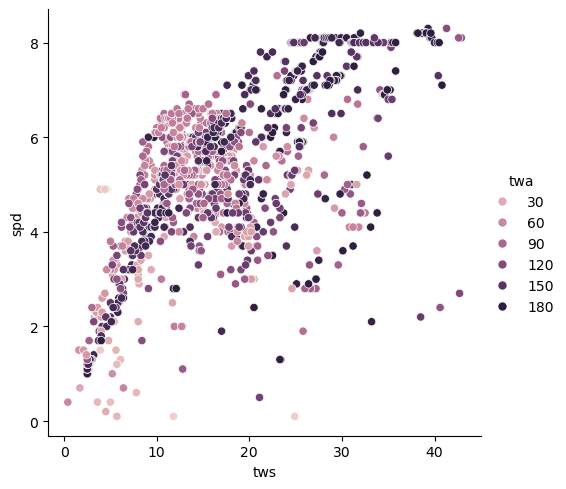

In [11]:
sns.relplot(df, x='tws', y='spd', hue='twa')

<Axes: xlabel='tws', ylabel='spd'>

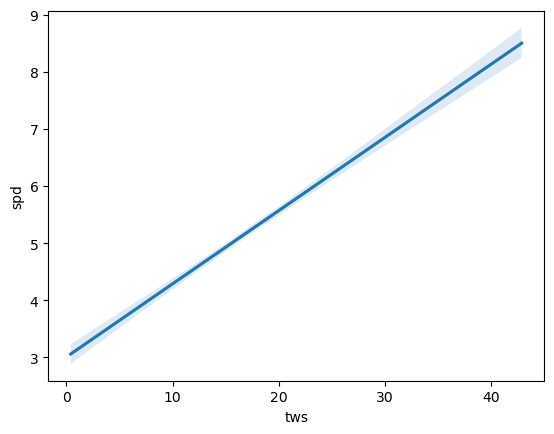

In [12]:
sns.regplot(df, x='tws', y='spd', scatter=False)

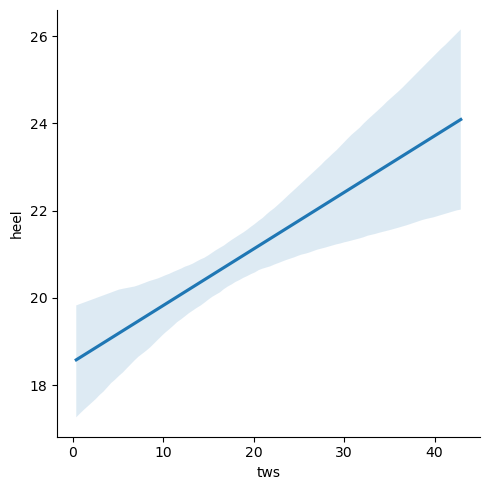

In [13]:
sns.lmplot(df, x='tws', y='heel', scatter=False)

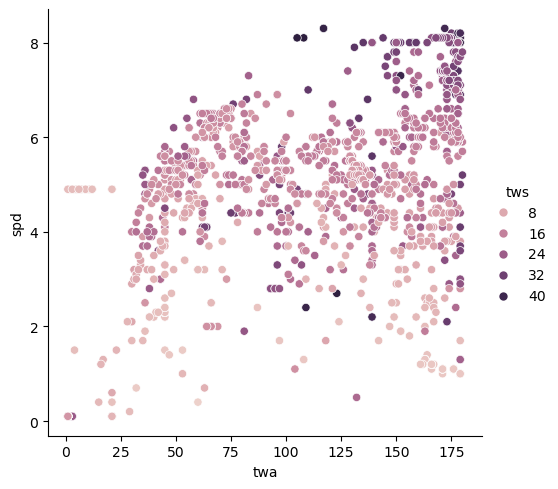

In [14]:
sns.relplot(df, x='twa', y='spd', hue='tws')

<Axes: ylabel='Count'>

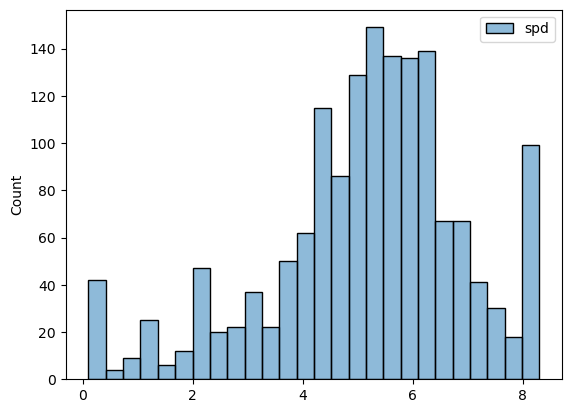

In [15]:
sns.histplot(df[['spd']])

<Axes: xlabel='tws', ylabel='Count'>

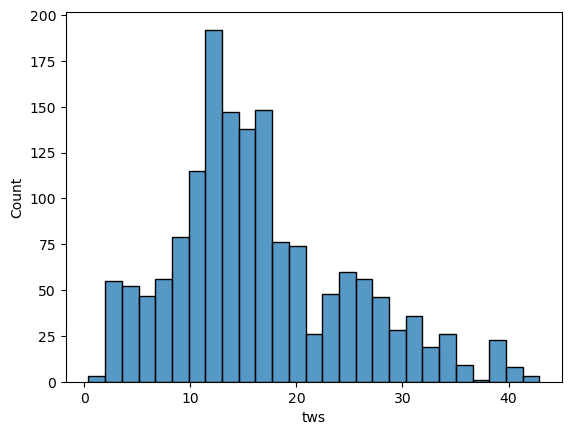

In [16]:
sns.histplot(df['tws'])

<Axes: ylabel='Count'>

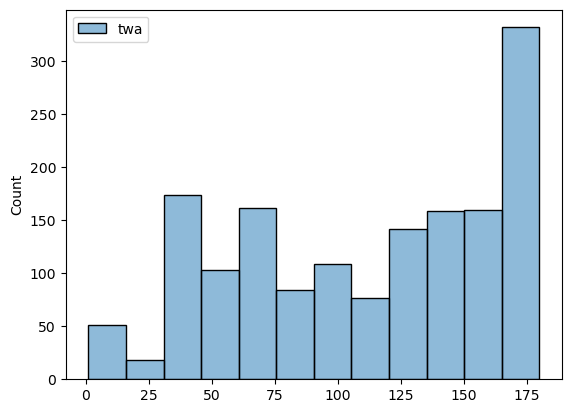

In [17]:
sns.histplot(df[['twa']])